## **Student Performance Indicator**

#### Life Cycle of Machine Learning Project

* Understanding The Problem Statement
* Data Collection
* Exploratory Data Analysis
* Data Pre-Processing
* Model Traning
* Choose Best Model

### 1. Problem Statement
* This project understands how the student's performance (test score) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test prepration cource.

### 2. Data Collection
* Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetld=74977
* The Data Consists 8 columns and 1000 rows.

#### 2.1 Import Data and Required Packages
Importing Pandas, Numpy, Matplotlib, Seaborn and Wraning Library.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Import the CSV Dataset as pandas DataFrame
df = pd.read_csv('data/StudentsPerformance.csv')
# Show the first 5 rows of the DataFrame
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
# Shape of the Dataset
df.shape

(1000, 8)

#### 2.2 Dataset Information
* gender : sex of students -> (Male/Female)
* race/ethnicity : ethnicity of students -> (Group A,B,C,D,E)
* parental level of education : parent's final education -> (bachelor's degree, some college, master's degree, associate's degree, high school)
* lunch : having lunch before test (standard or free/reduced)
* test preparation cource : complete or not complete before test
* math score
* reading score
* writing score

### 3. Data Checks to Perform 
* Check Missing Valuse
* Check Duplicates
* Check Datatypes
* Check The Number of Unique Value of Each Columns
* Chech Statistics of Dataset
* Check Various Categories Presents in Categorical Columns

In [6]:
# Check Missing Values
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

observation : There is no missing values in my dataset

In [7]:
# Check Duplicated
df.duplicated().sum()

np.int64(0)

observation : There is no duplicated values in my dataset

In [8]:
# Check Datatype
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [9]:
# Checking The Number of Unique Values os Each Columns
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [10]:
# Check The Statistics of The Data
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Insight
* From above description of numerical data all means are very close to each other - between 66 and 68.05.
* All standard deviation  are also close - between 14.6 and 15.19.
* While there is a minimum score 0 for math, for writing minimum is much higher = 10 and for reading much higher = 17.

In [11]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [12]:
# Exploring Data

print("Categories in 'gender' variables: ",end=" ")
print(df['gender'].unique().tolist())

print("Categories in 'race/ethnicity' variables: ", end=" ")
print(df['race/ethnicity'].unique().tolist())

print("Categories in 'parental level of education' variables: ", end=" ")
print(df['parental level of education'].unique().tolist())

print("Categories in 'lunch' variables: ", end=" ")
print(df['lunch'].unique().tolist())

print("Categories in 'test preparation course' variables: ", end=" ")
print(df['test preparation course'].unique().tolist())

Categories in 'gender' variables:  ['female', 'male']
Categories in 'race/ethnicity' variables:  ['group B', 'group C', 'group A', 'group D', 'group E']
Categories in 'parental level of education' variables:  ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
Categories in 'lunch' variables:  ['standard', 'free/reduced']
Categories in 'test preparation course' variables:  ['none', 'completed']


In [13]:
# Define numerical and categorical feature
numerical_feature = [feature for feature in df.columns if df[feature].dtype != 'string']
categorical_feature = [feature for feature in df.columns if df[feature].dtype == 'string']

# Print Columns
print(f"We have {len(numerical_feature)} numerical feature : {numerical_feature}")
print(f"We have {len(categorical_feature)} categorical feature : {categorical_feature}")


We have 3 numerical feature : ['math score', 'reading score', 'writing score']
We have 5 categorical feature : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [14]:
# Adding columns for "Total Score" and "Average"
df["total score"] = df["math score"] + df["reading score"] + df["writing score"] 
df["average"] = df["total score"]/3

In [15]:
reading_full = df[df['reading score'] == 100]['average'].count()
writting_full = df[df['writing score'] == 100]['average'].count()
math_full = df[df['math score'] == 100]['average'].count()

print(f"Number of students with full marks in Maths: {math_full}")
print(f"Number of students with full marks in Writing: {writting_full}")
print(f"Number of students with full marks in Reading: {reading_full}")

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [16]:
reading_less_20 = df[df['reading score'] <= 20]['average'].count()
writting_less_20 = df[df['writing score'] <= 20]['average'].count()
math_less_20 = df[df['math score'] <= 20]['average'].count()

print(f"Number of students with less than 20 marks in Maths: {math_less_20}")
print(f"Number of students with less than 20 marks in Writing: {writting_less_20}")
print(f"Number of students with less than 20 marks in Reading: {reading_less_20}")

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


Insight
* From above we get students have performed the worst in Maths
* Best performance in reading section

### 4. Exploring Data (Visulization)

#### 4.1 Visulize average score distribution to make some conclusion
* Histogram
* Kernel Distribution Function (KDE)

<Axes: xlabel='average', ylabel='Count'>

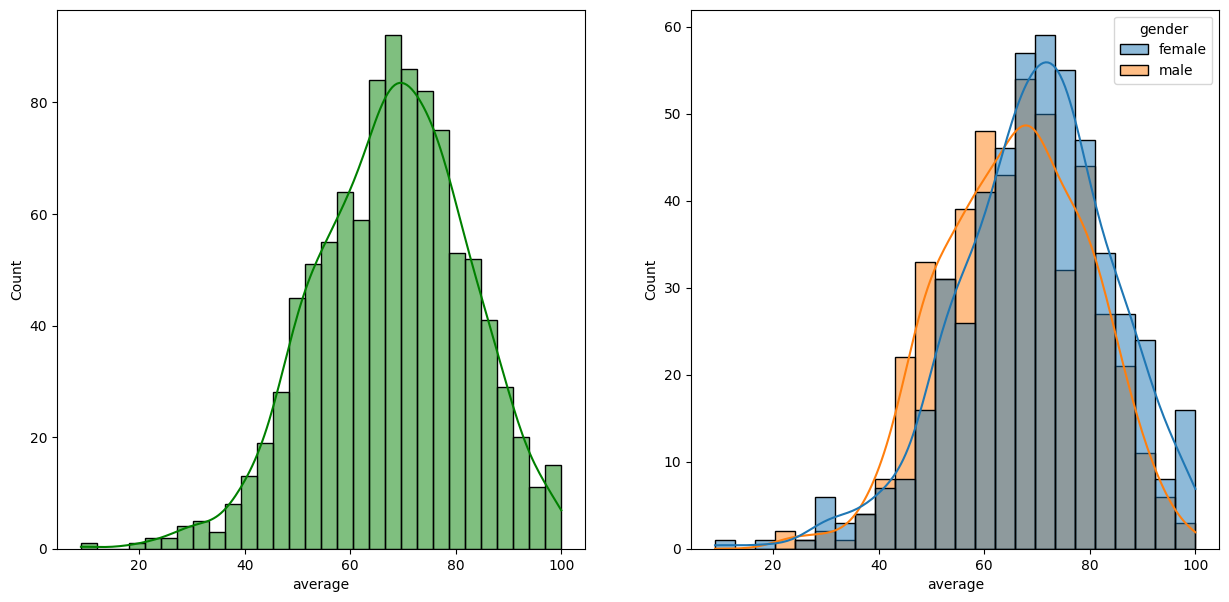

In [17]:
# Histogram & KDE
fig, axs = plt.subplots(1, 2, figsize= (15,7))
plt.subplot(121)
sns.histplot(data=df, x='average', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='average', kde=True, hue='gender')

<Axes: xlabel='total score', ylabel='Count'>

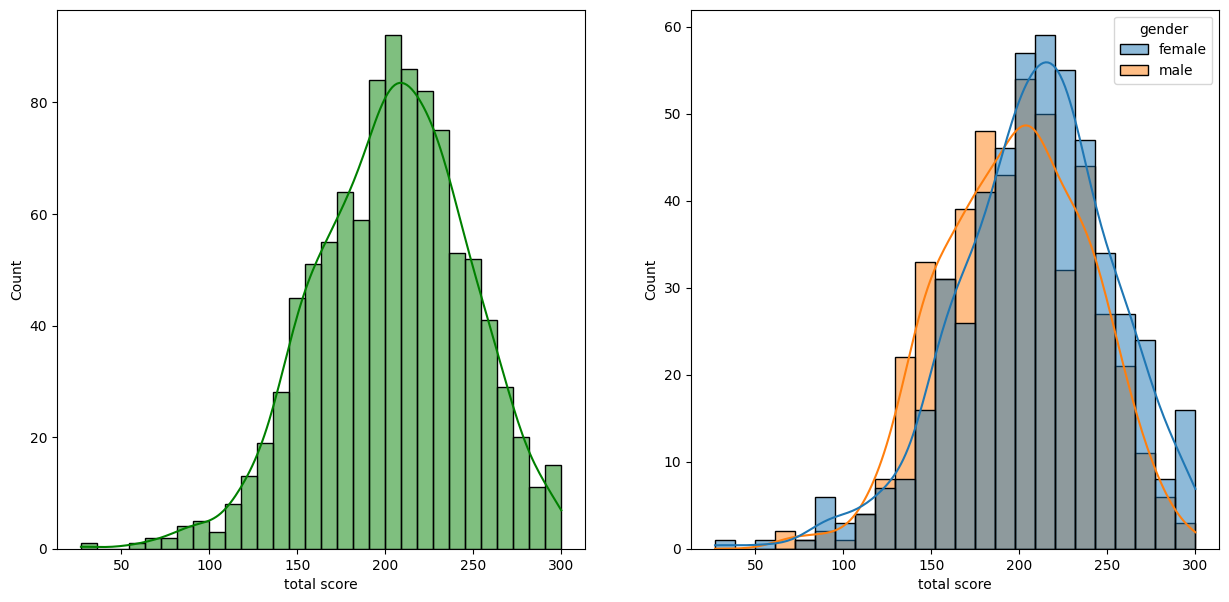

In [18]:
# Histogram & KDE
fig, axs = plt.subplots(1, 2, figsize= (15,7))
plt.subplot(121)
sns.histplot(data=df, x='total score', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='total score', kde=True, hue='gender')

Insights
* Female students tend to perform well then male students.

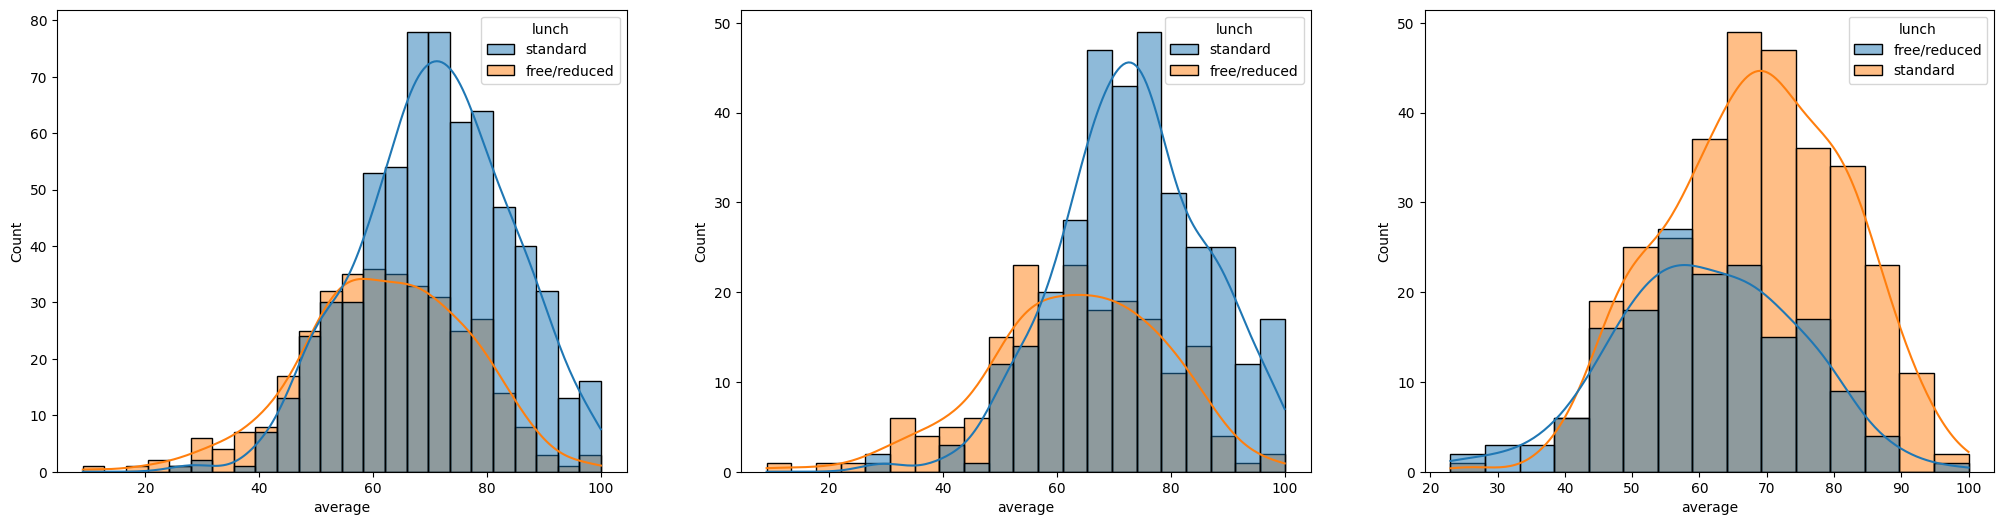

In [19]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(131)
sns.histplot(data=df, x='average', kde=True, hue='lunch')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='lunch')
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='lunch')
plt.show()

Insights
* Standard lunch helps perform well in exams.
* Standard lunch helps perform well in exams be it a male or a female.

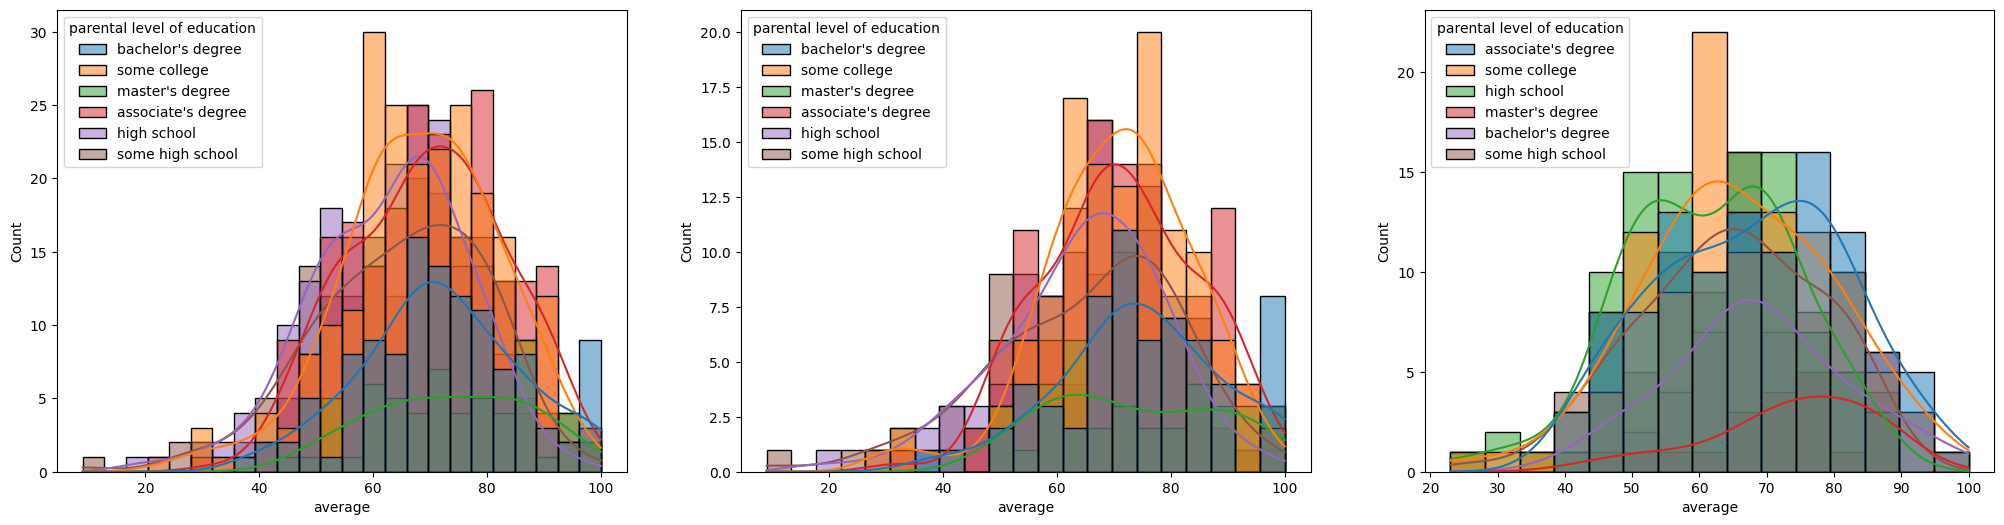

In [20]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(131)
sns.histplot(data=df, x='average', kde=True, hue='parental level of education')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='parental level of education')
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='parental level of education')
plt.show()

Insights
* In general parent's eduction don't help student perform well in exam.
* 2nd plot we can see there is no effect of parent's education on female students.
* 3nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend perform well in exam.


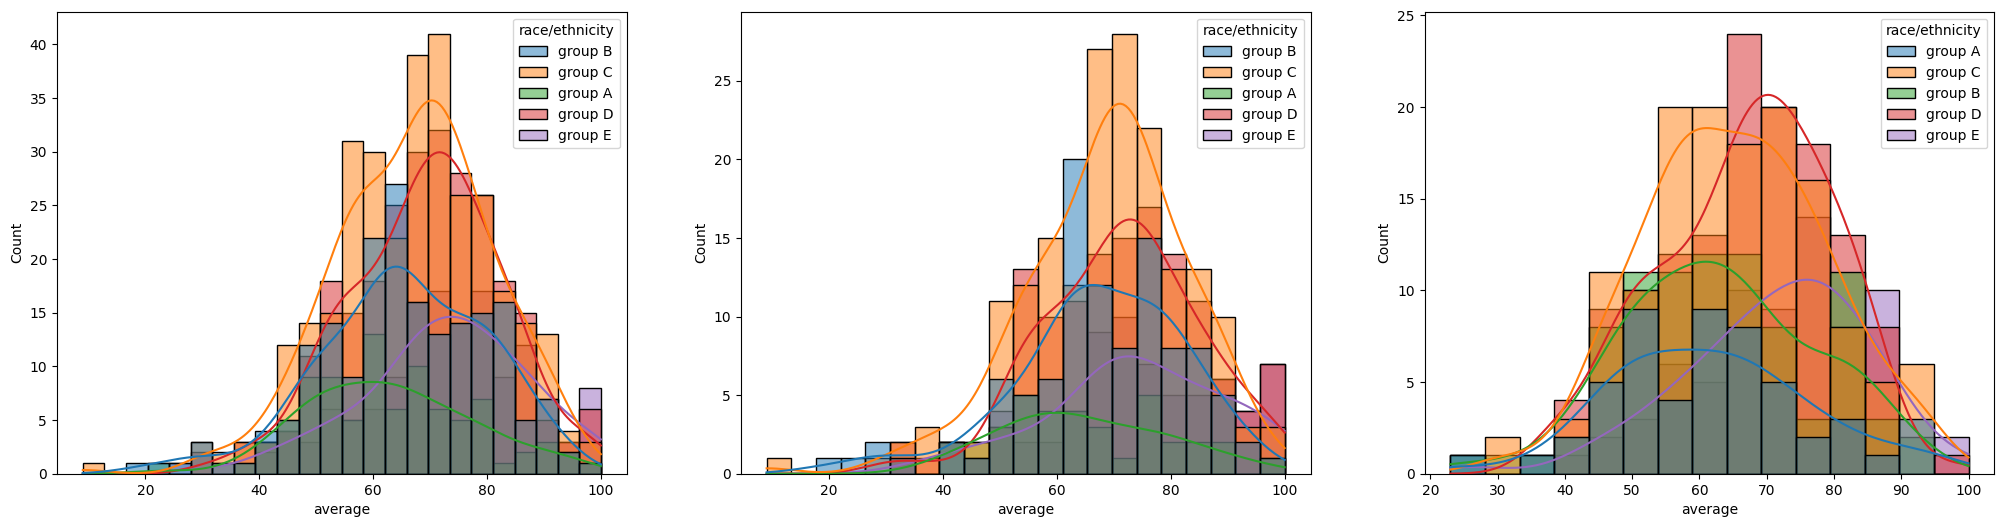

In [21]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(131)
sns.histplot(data=df, x='average', kde=True, hue='race/ethnicity')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='race/ethnicity')
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='race/ethnicity')
plt.show()

Insights
* Students of group A and group B tends to perform poorly in exam.
* Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female.

#### 4.2 Maximum score of student in all three subjects

<Axes: title={'center': 'WRITING SCORES'}, ylabel='writing score'>

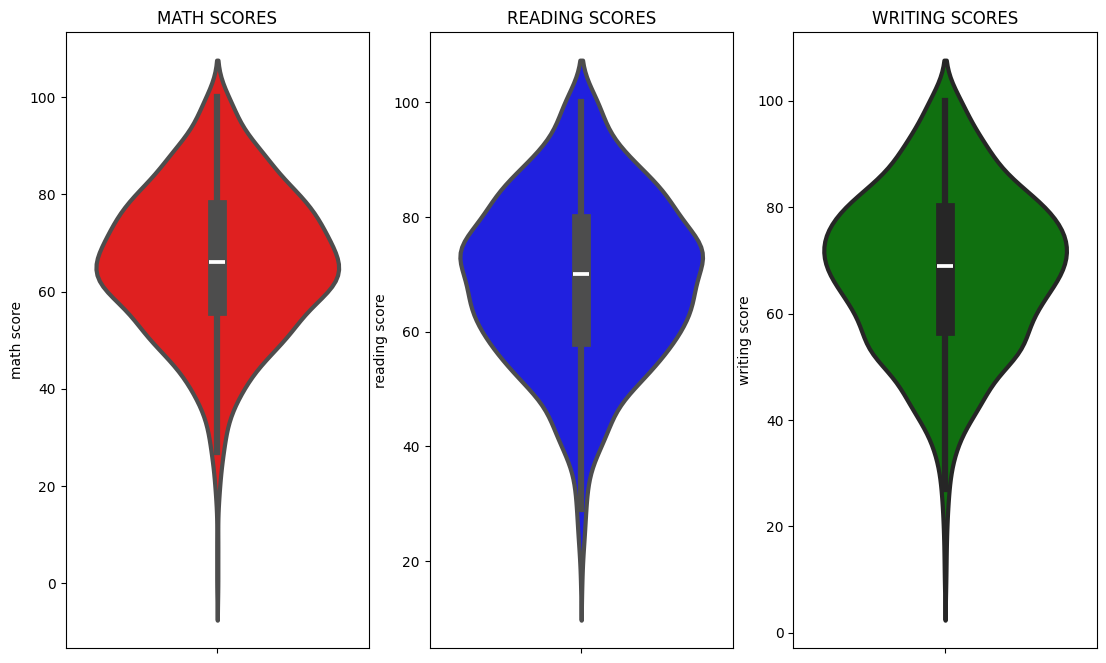

In [22]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math score', data=df, color='red', linewidth=3)

plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading score', data=df, color='blue', linewidth=3)

plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing score', data=df, color='green', linewidth=3)

Insights
* From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whether in reading and writing most of them score 50-80.

#### 4.3 Multivariate analysis using piplot

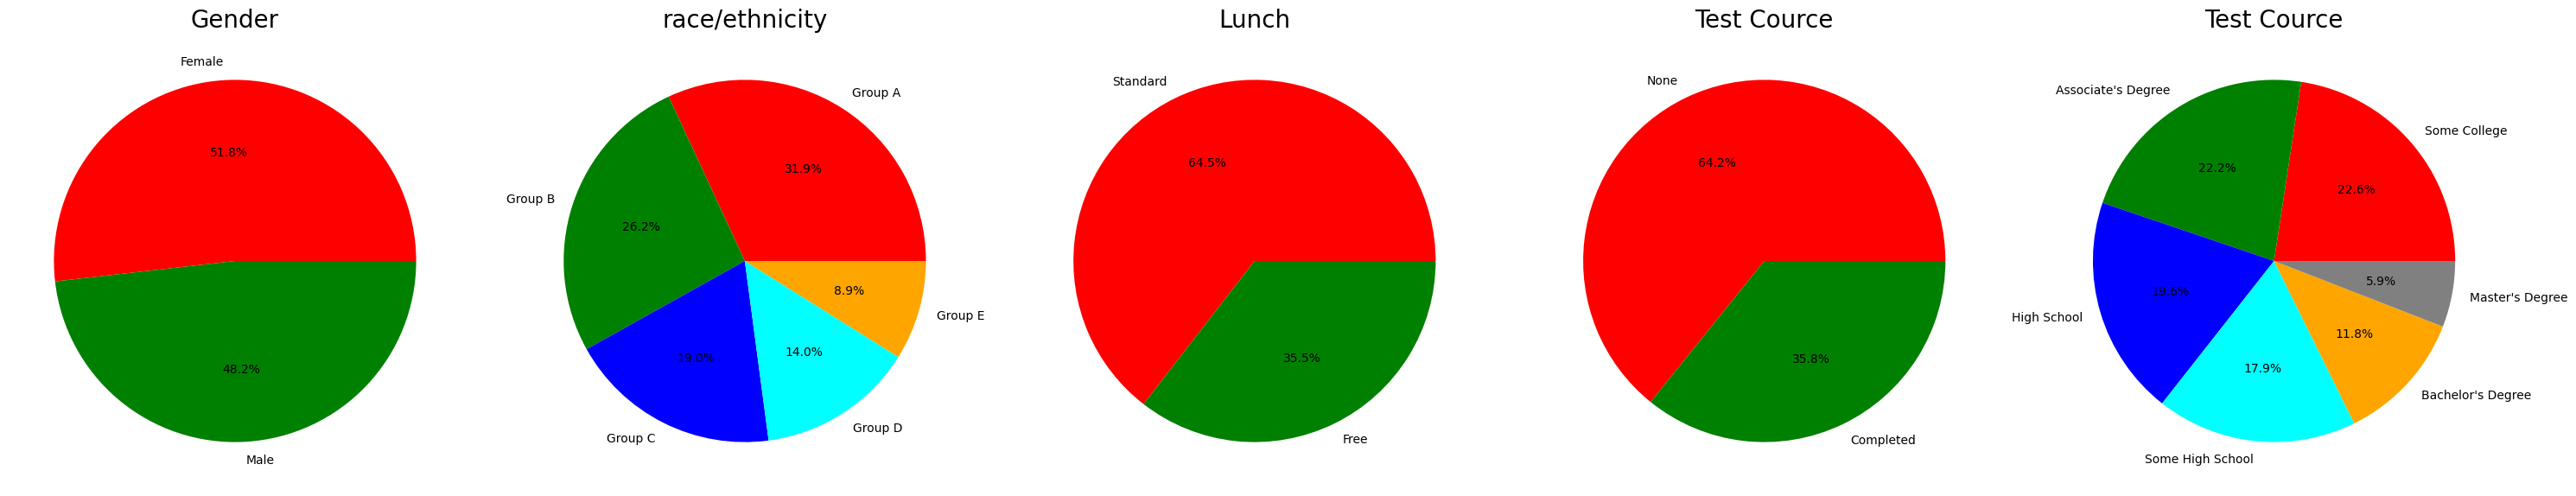

In [23]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red', 'green']

plt.pie(size, colors=color, labels=labels, autopct='%1.1f%%')
plt.title('Gender', fontsize=20)
plt.axis('off')

plt.subplot(1, 5, 2)
size = df['race/ethnicity'].value_counts()
labels = 'Group A', 'Group B', 'Group C', 'Group D', 'Group E',
color = ['red', 'green', 'blue', 'cyan', 'orange']

plt.pie(size, colors=color, labels=labels, autopct='%1.1f%%')
plt.title('race/ethnicity', fontsize=20)
plt.axis('off')

plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red', 'green']

plt.pie(size, colors=color, labels=labels, autopct='%1.1f%%')
plt.title('Lunch', fontsize=20)
plt.axis('off')

plt.subplot(1, 5, 4)
size = df['test preparation course'].value_counts()
labels = 'None', 'Completed'
color = ['red', 'green']

plt.pie(size, colors=color, labels=labels, autopct='%1.1f%%')
plt.title('Test Cource', fontsize=20)
plt.axis('off')

plt.subplot(1, 5, 5)
size = df['parental level of education'].value_counts()
labels = 'Some College', "Associate's Degree", 'High School', 'Some High School', "Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan', 'orange', 'grey']

plt.pie(size, colors=color, labels=labels, autopct='%1.1f%%')
plt.title('Test Cource', fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.grid()

plt.show()


Insights
* Number of Male and Female students is almost equal
* Number of students are greatest in Group C
* Number of students who have standard lunch are greater
* Number students who have not enrolled in any test preparation course is greater 
* Number of Students whose parental education is "Some college" is greater followed closed by "Associate's Degree"

### 4.4 Feature Wise Visulization

#### 4.4.1 Gender Column
* How is Distribution of gender?
* Is gender has any impact on student's performance?

### Univariate Analysis ( How is Distribution of Gender? )

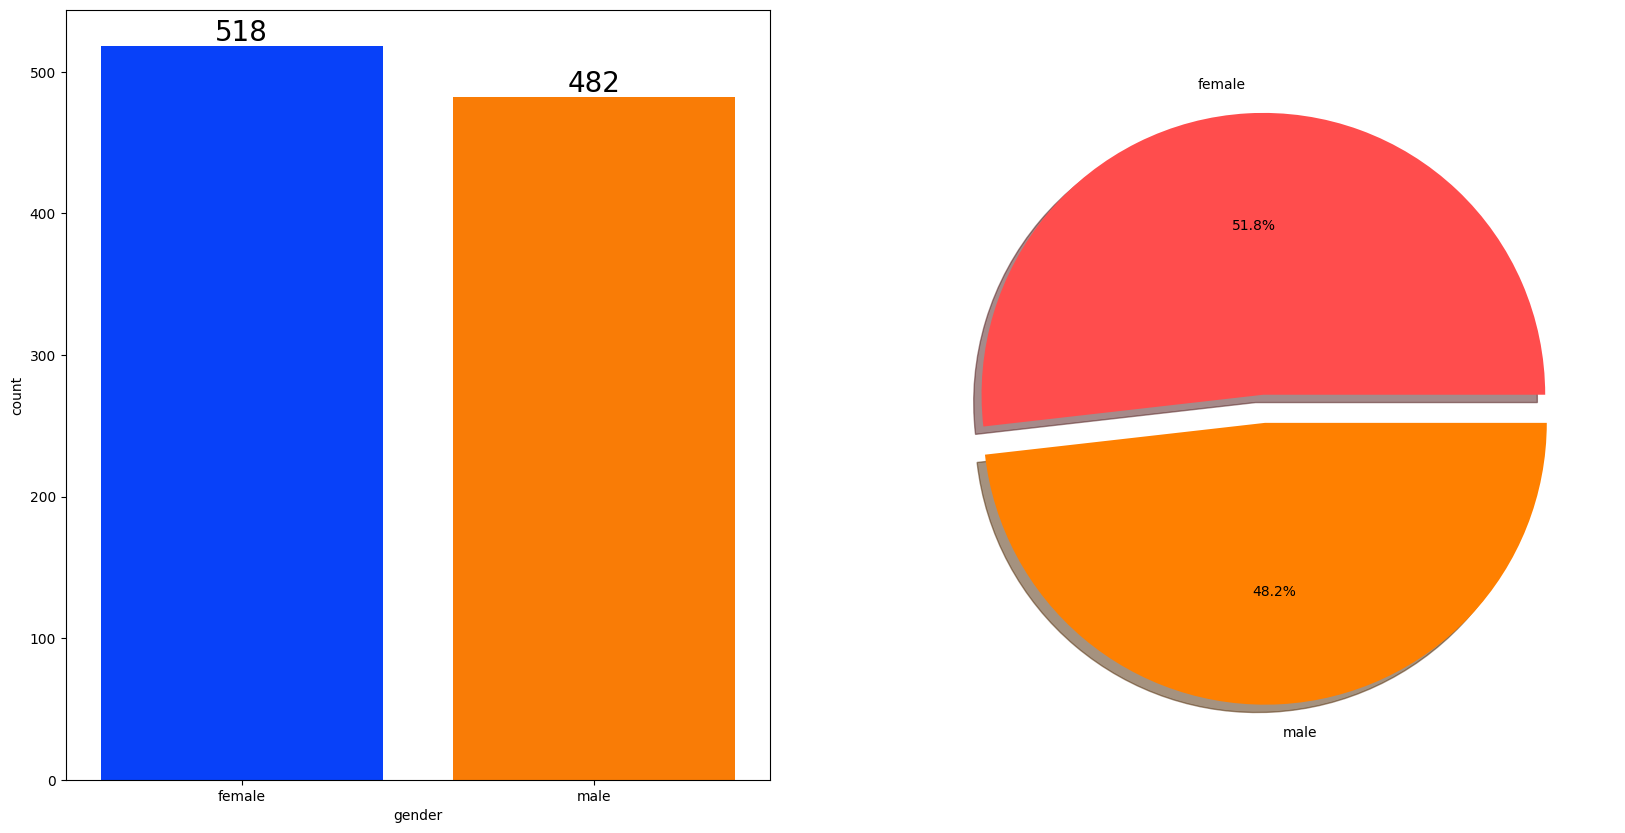

In [24]:
f, ax = plt.subplots(1, 2, figsize = (20,10))
sns.countplot(x=df['gender'], data=df, palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)


plt.pie(x=df['gender'].value_counts(), labels=df['gender'].value_counts().index, explode=[0,0.1], autopct='%1.1f%%', shadow=True, colors=['#ff4d4d', '#ff8000'])
plt.show()

Insights
* Gender has balanced data with female students are 518(48%) and male student are 482(52%)

### Bivariate Analysis (Is gender has any impact on student's performance?)

In [25]:
# gender_group = df.groupby('gender')
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group



,math score,reading score,writing score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


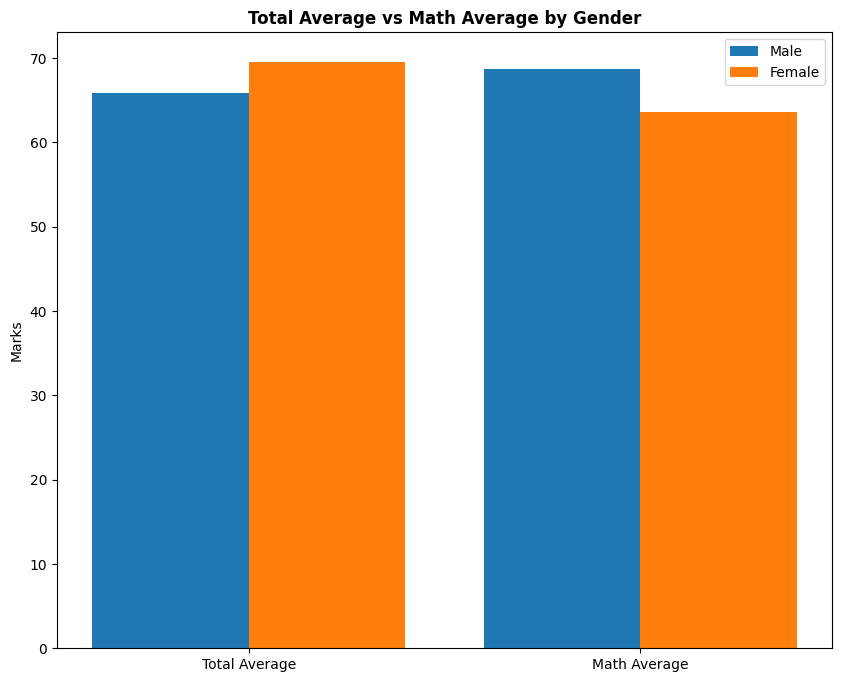

In [26]:
plt.figure(figsize=(10, 8))

X = ['Total Average', 'Math Average']

female_scores = [
    gender_group.loc['female', 'average'],
    gender_group.loc['female', 'math score']
]

male_scores = [
    gender_group.loc['male', 'average'],
    gender_group.loc['male', 'math score']
]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total Average vs Math Average by Gender", fontweight='bold')
plt.legend()
plt.show()

Insights
* On an average females have a better overall score than male.
* where as males have scored higher in Maths.

#### 4.4.2 Race/Ehnicity Column
* How is Group wise Distribution
* Is Race/Ehnicity has any impact on student's performance?


#### Univariate Analysis (How is Group wise Distribution?)

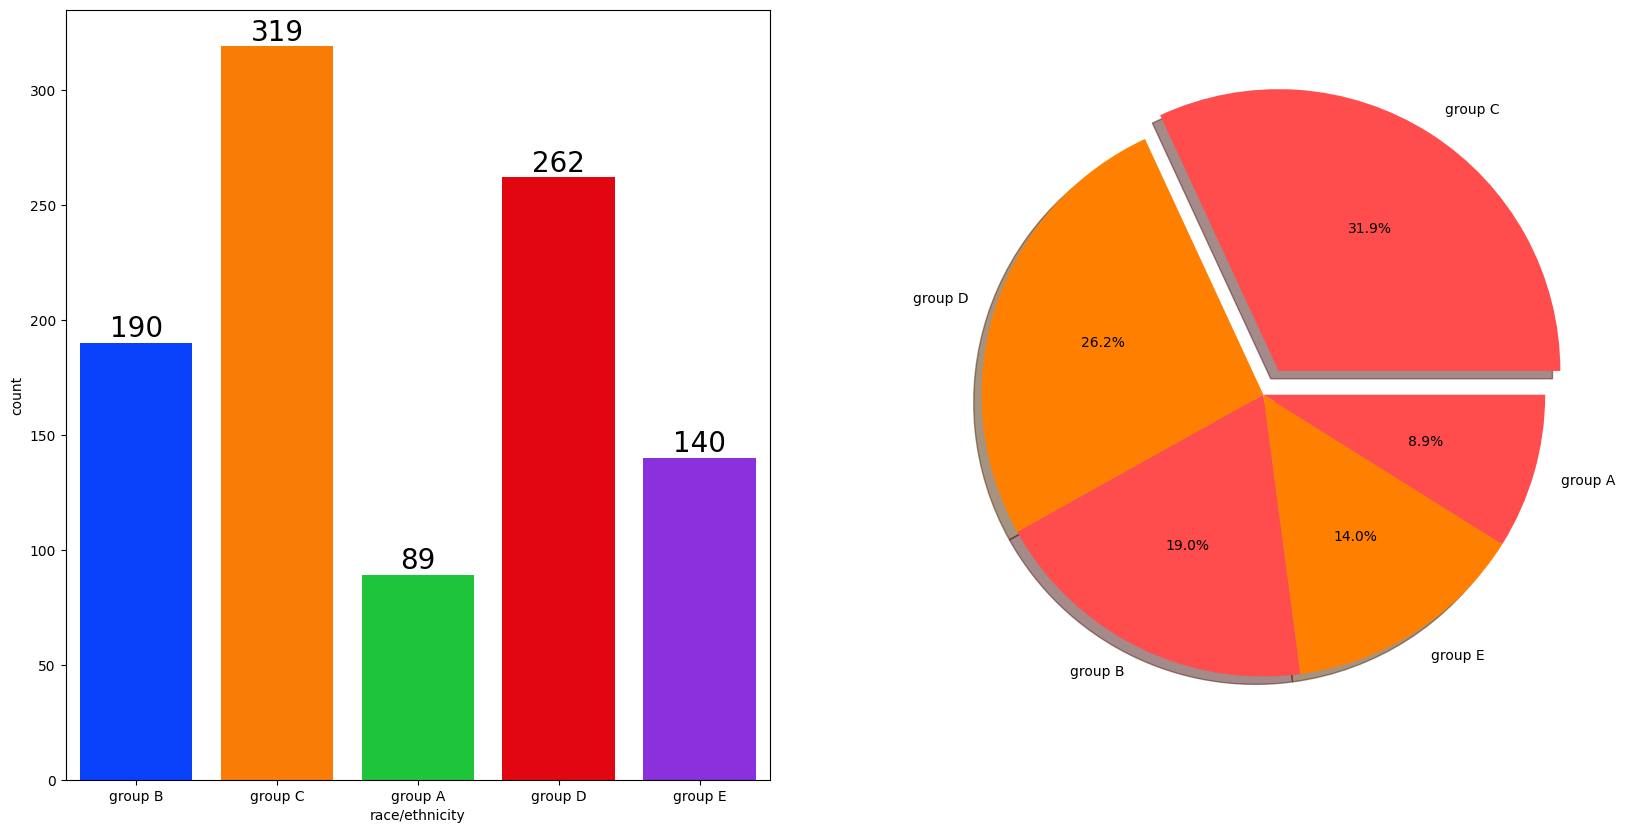

In [27]:
f, ax = plt.subplots(1, 2, figsize = (20,10))
sns.countplot(x=df['race/ethnicity'], data=df, palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)


plt.pie(x=df['race/ethnicity'].value_counts(), labels=df['race/ethnicity'].value_counts().index, explode=[0.1,0,0,0,0], autopct='%1.1f%%', shadow=True, colors=['#ff4d4d', '#ff8000'])
plt.show()

Insights

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

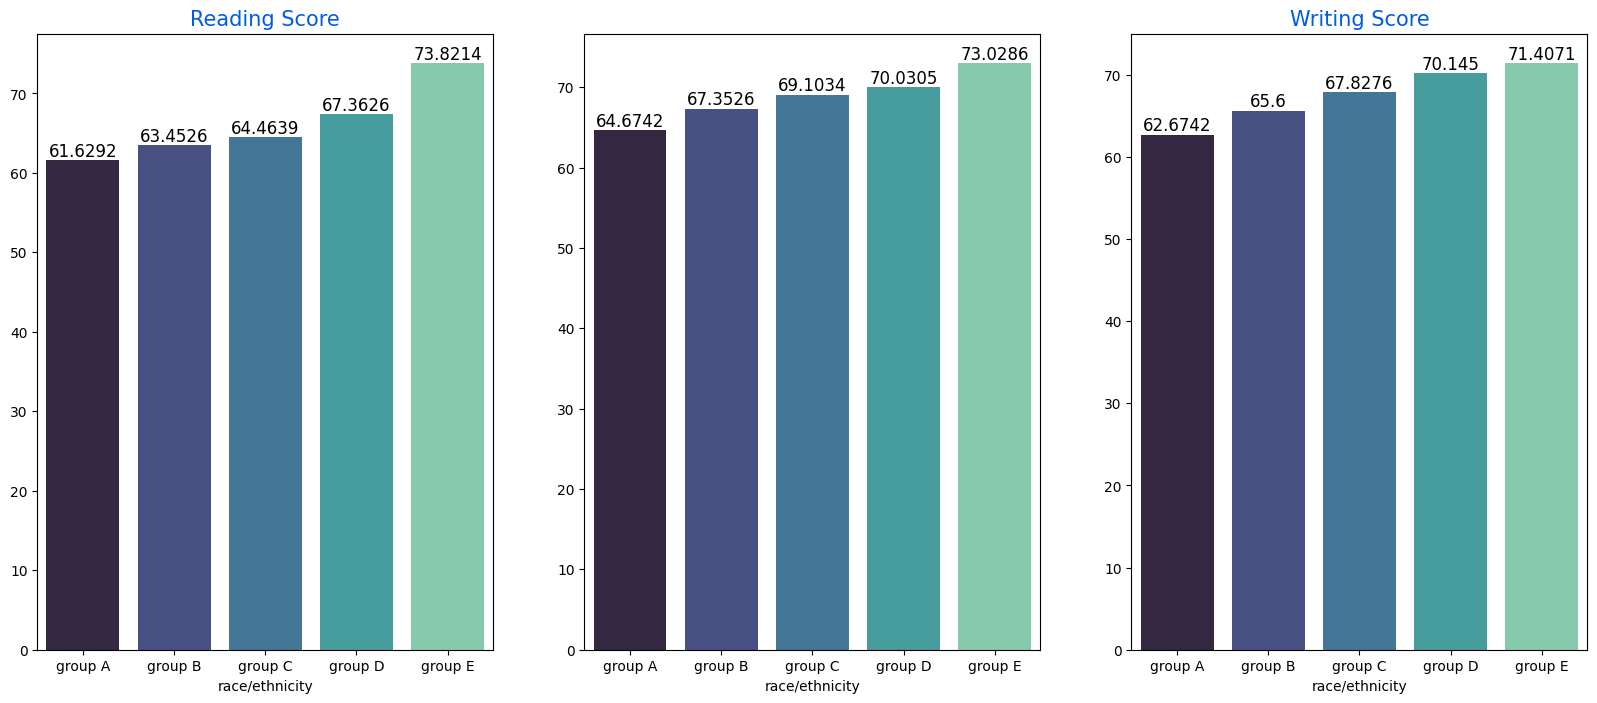

In [28]:
Group_data2 = df.groupby('race/ethnicity')

f, ax = plt.subplots(1,3,figsize=(20,8))

sns.barplot(x=Group_data2['math score'].mean().index, y=Group_data2['math score'].mean().values,palette='mako', ax=ax[0])
ax[0].set_title('Math Score', color='#005ce6', size=15)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=12)

sns.barplot(x=Group_data2['reading score'].mean().index, y=Group_data2['reading score'].mean().values,palette='mako', ax=ax[1])
ax[0].set_title('Reading Score', color='#005ce6', size=15)

for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=12)

sns.barplot(x=Group_data2['writing score'].mean().index, y=Group_data2['writing score'].mean().values,palette='mako', ax=ax[2])
ax[2].set_title('Writing Score', color='#005ce6', size=15)

for container in ax[2].containers:
    ax[2].bar_label(container, color='black', size=12)
    


Insights
* Group E studentshave scored the highest marks.
* Group A students have scored the lowest marks.
* Students from a lower Socioeconomic status have a lower avg in all cource subjects.

#### 4.4.3 Parental Level of Education
* What is educational background of student's parent?
* Is parental education has any impact on student's performance

#### Univariate Analysis (What is educational background of student's parent?)

Text(0.5, 1.0, 'Comparison of Parental Education')

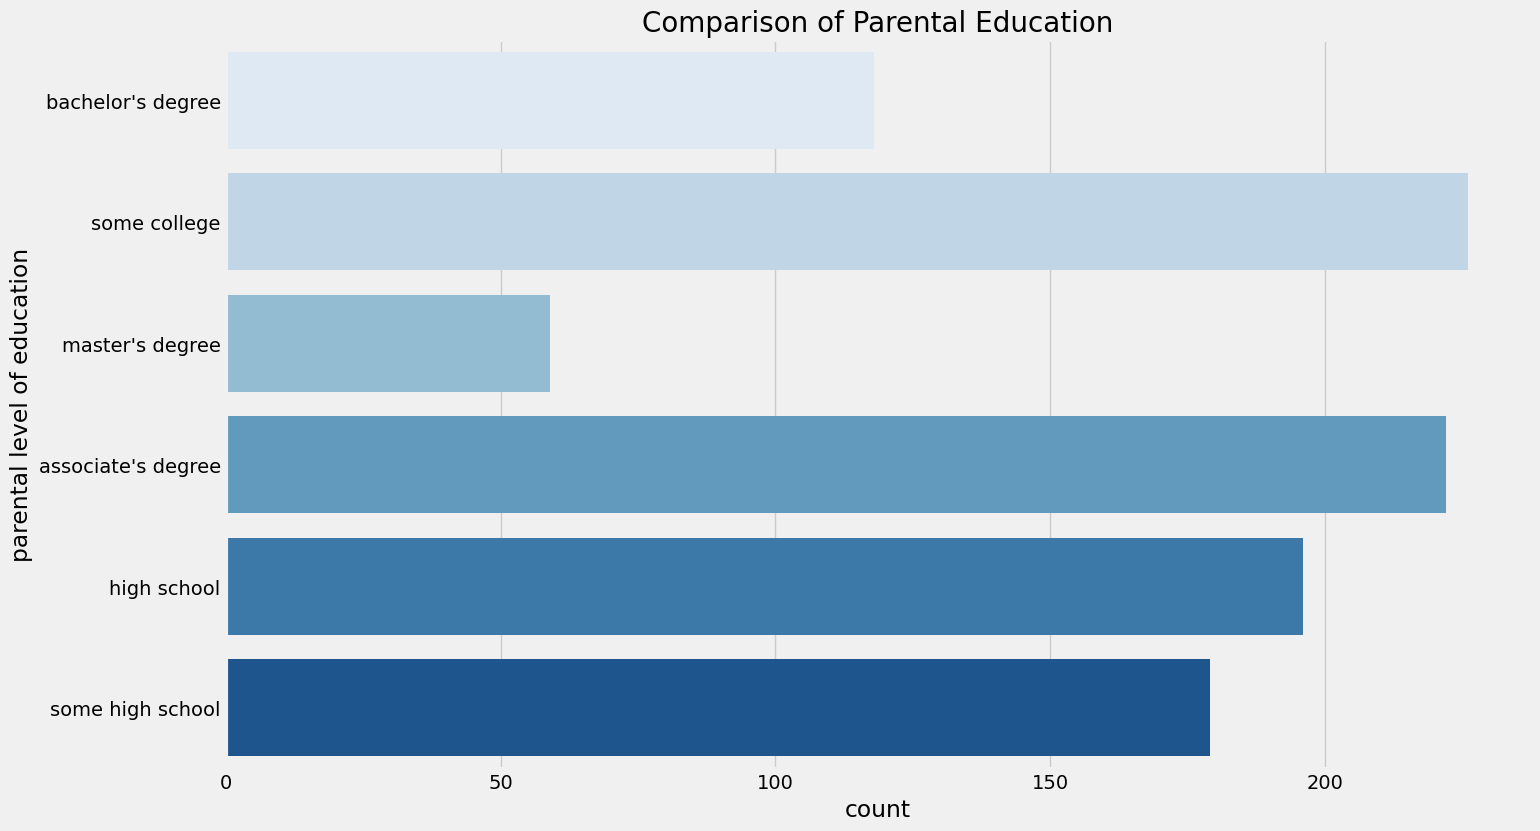

In [29]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental level of education'], palette='Blues')
plt.title('Comparison of Parental Education', fontweight=30, fontsize=20)

Insights
* Largest of parents are from some college.

#### Bivariate Analysis ( Is parental education has any impact on student's performance ? )

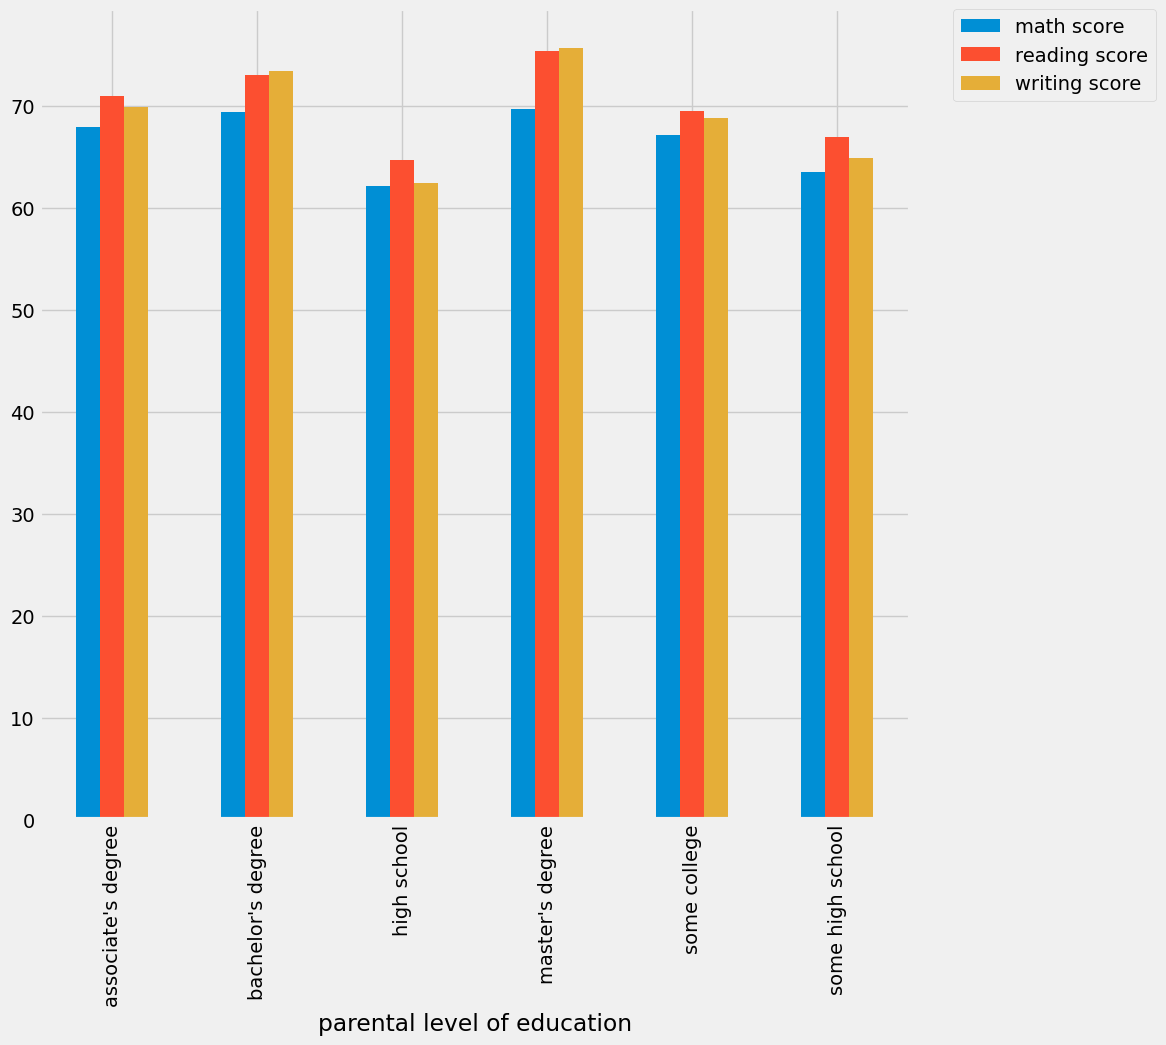

In [30]:
df.groupby('parental level of education')[['math score','reading score','writing score']].mean().plot(kind='bar', figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

Insights
* The score of student whose parents process master and bachelor level education are higher than others.

#### 4.4.4 Lunch Column
* Which type of lunch is most common among students?
* What is the effect of lunch type on test results?

#### Univariate Analysis ( Which type of lunch is most common amoung studentd ? )

In [31]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'total score', 'average'],
      dtype='str')

In [32]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


Text(0.5, 1.0, 'Comparison of Different Types of Lunch')

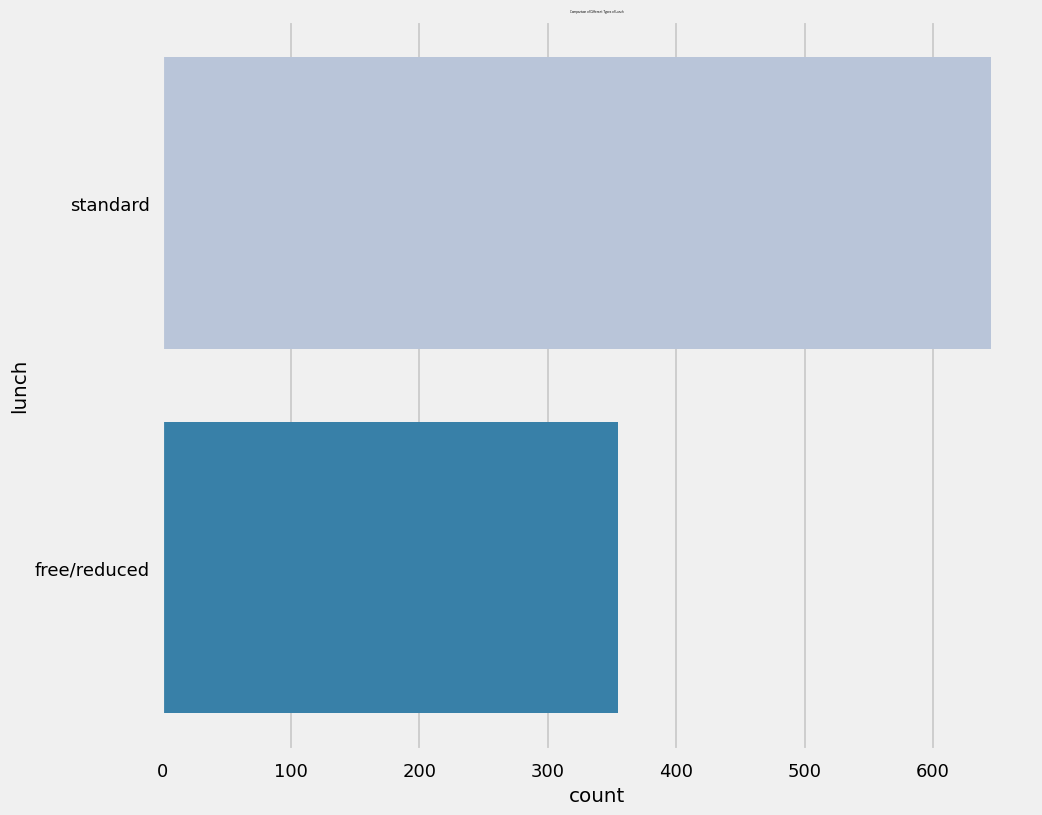

In [ ]:
plt.rcParams['figure.figsize'] = (15 ,9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(df['lunch'], palette='PuBu')
plt.title('Comparison of Different Types of Lunch', fontweight=30, fontsize=2)

Insights
* Students being served Standard lunch was more than free lunch.

#### Bivariate Analysis ( Is lunch type intake has any impact on student's performance ? )

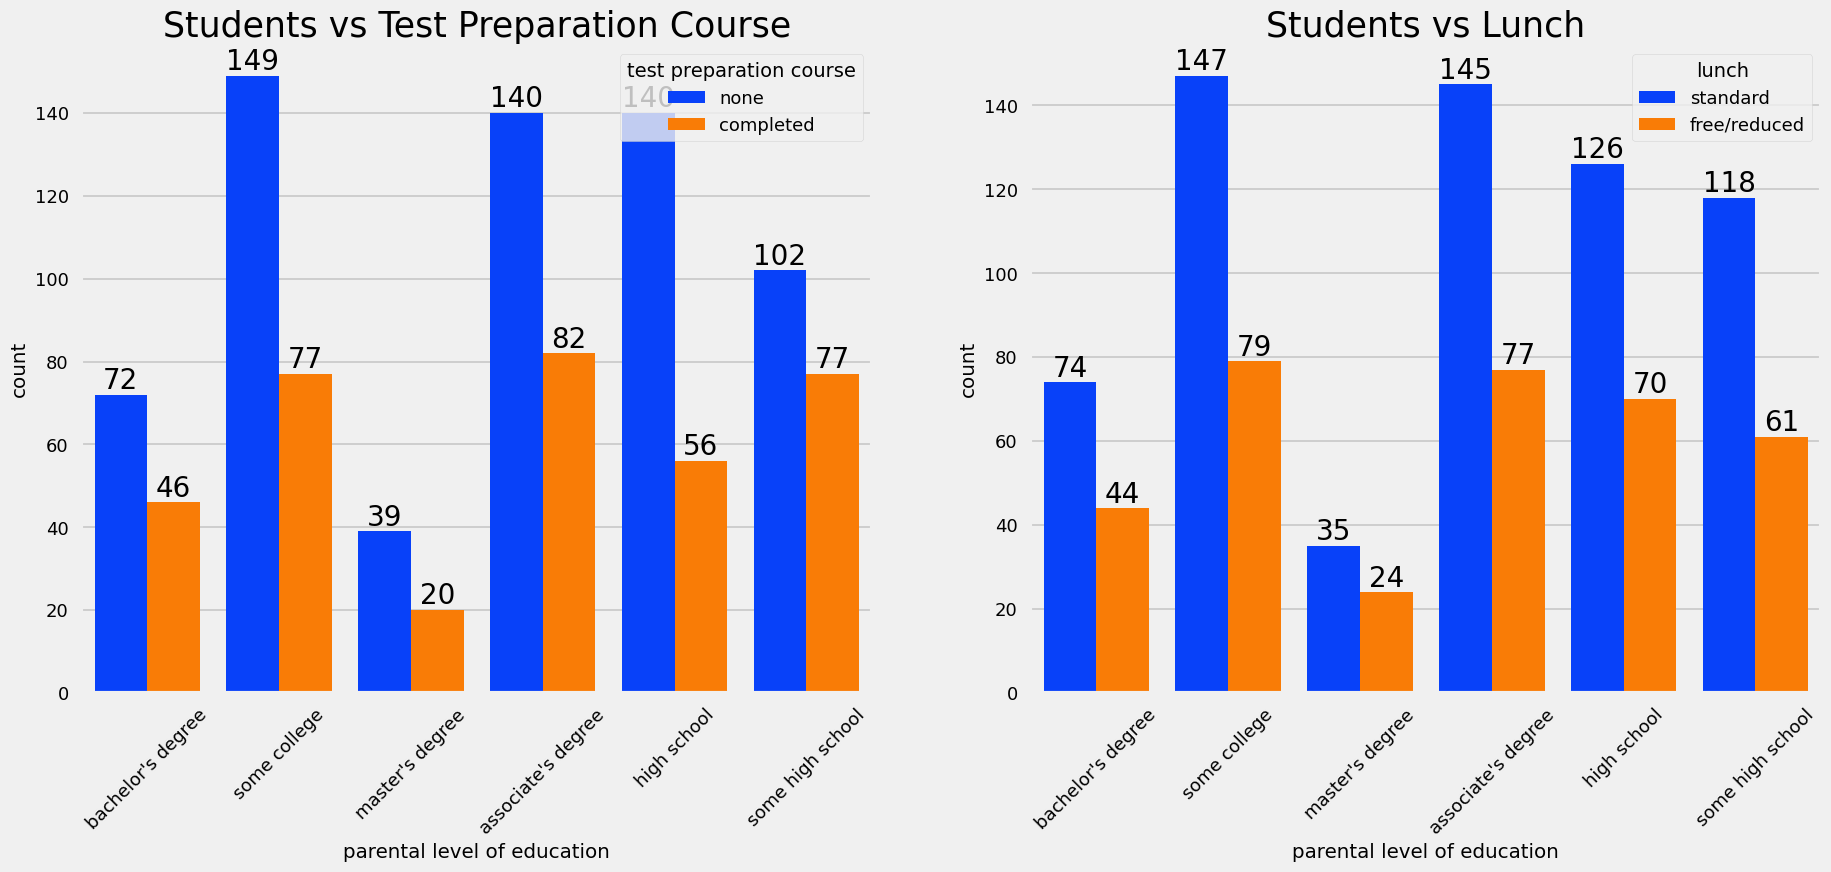

In [52]:
f, ax = plt.subplots(1,2,figsize=(20,8))

sns.countplot(x=df['parental level of education'], data=df, palette='bright', hue='test preparation course', saturation=0.95, ax=ax[0])
ax[0].set_title('Students vs Test Preparation Course', color='black', size=25)

ax[0].tick_params(axis='x', rotation=45)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

sns.countplot(x=df['parental level of education'], data=df, palette='bright', hue='lunch', saturation=0.95, ax=ax[1])
ax[1].set_title('Students vs Lunch', color='black', size=25)

ax[1].tick_params(axis='x', rotation=45)

for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=20)


Insights
* Students who get Standard Lunch tend to perform better than students who got free/reduced lunch.

#### Test Preparation Course Column 
* Whiich type of lunch is most common amoung students ?
* Is Test prepration course has any impact on student's performance

#### Bivariate Analysis ( Is Test preparation course has any impact on student's performance ? )

<Axes: xlabel='lunch', ylabel='math score'>

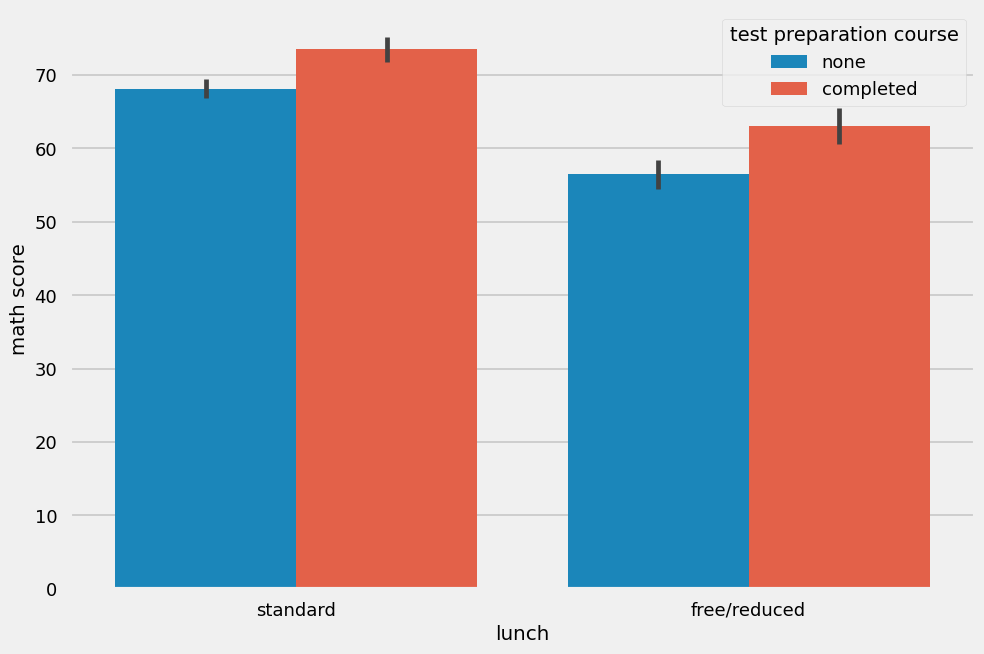

In [35]:
sns.barplot(x=df['lunch'], y=df['math score'], hue=df['test preparation course'])

<Axes: xlabel='lunch', ylabel='reading score'>

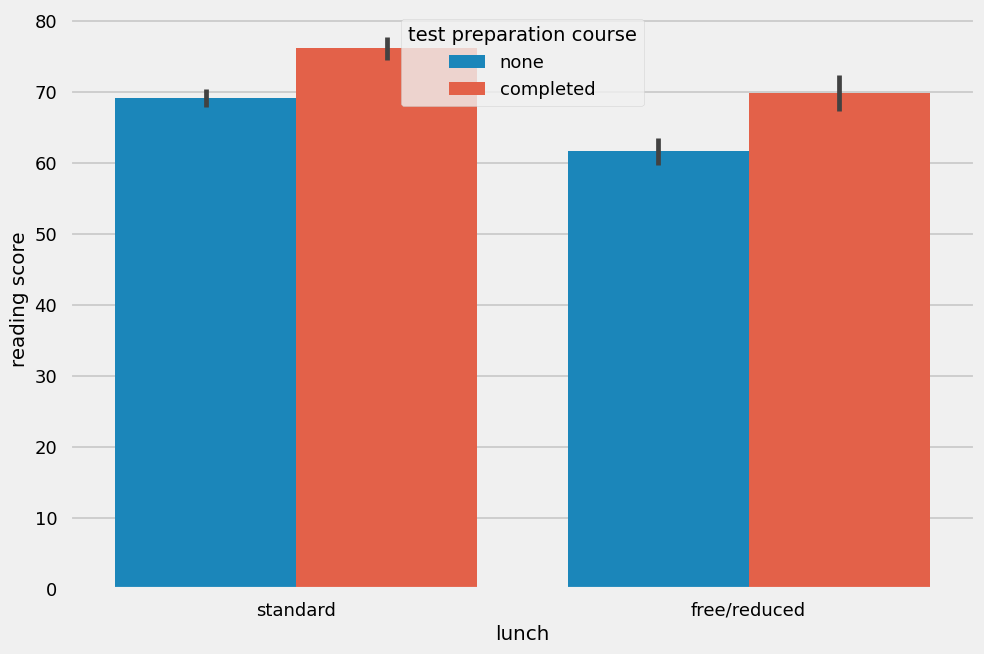

In [36]:
sns.barplot(x=df['lunch'], y=df['reading score'], hue=df['test preparation course'])

<Axes: xlabel='lunch', ylabel='writing score'>

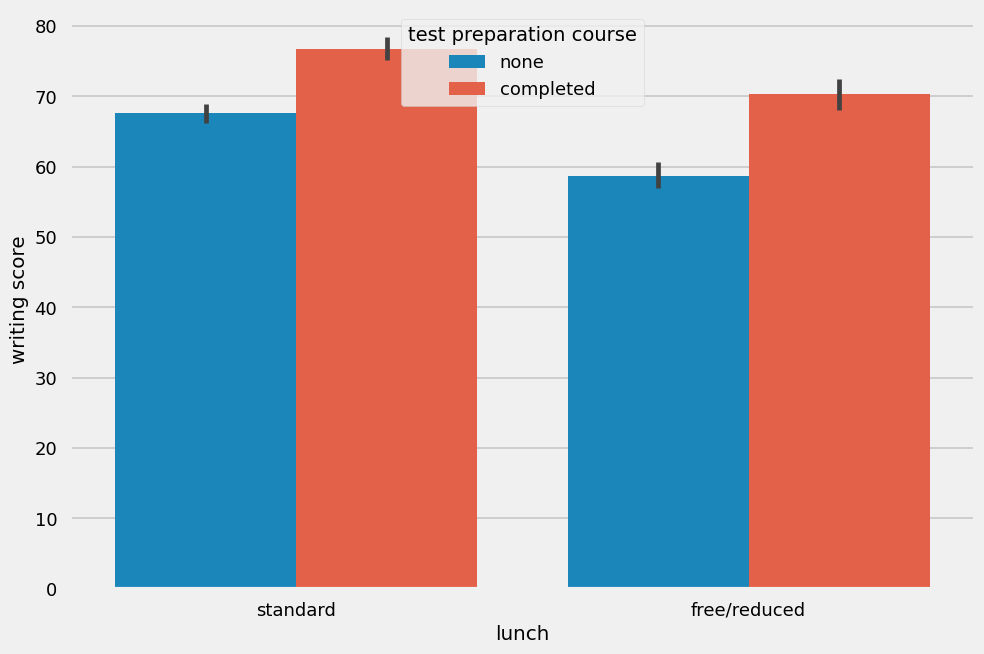

In [37]:
sns.barplot(x=df['lunch'], y=df['writing score'], hue=df['test preparation course'])

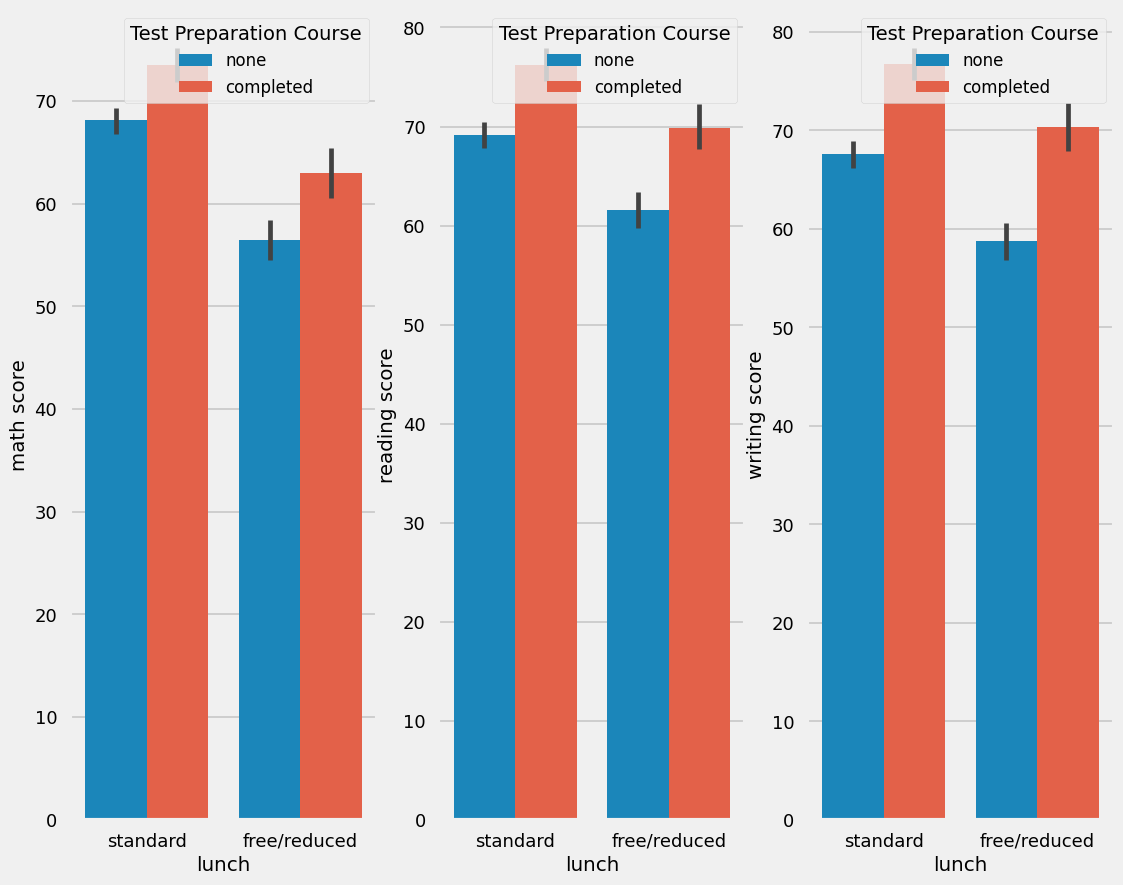

In [38]:
plt.figure(figsize=(12,10))

plt.subplot(1,3,1)
sns.barplot(x=df['lunch'], y=df['math score'], hue=df['test preparation course'])
plt.legend(title='Test Preparation Course',fontsize=12,title_fontsize=14)

plt.subplot(1,3,2)
sns.barplot(x=df['lunch'], y=df['reading score'], hue=df['test preparation course'])
plt.legend(title='Test Preparation Course',fontsize=12,title_fontsize=14)

plt.subplot(1,3,3)
sns.barplot(x=df['lunch'], y=df['writing score'], hue=df['test preparation course'])
plt.legend(title='Test Preparation Course',fontsize=12,title_fontsize=14)
# plt.tight_layout()

Insights
* Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

#### Checking Outliers

<Axes: ylabel='average'>

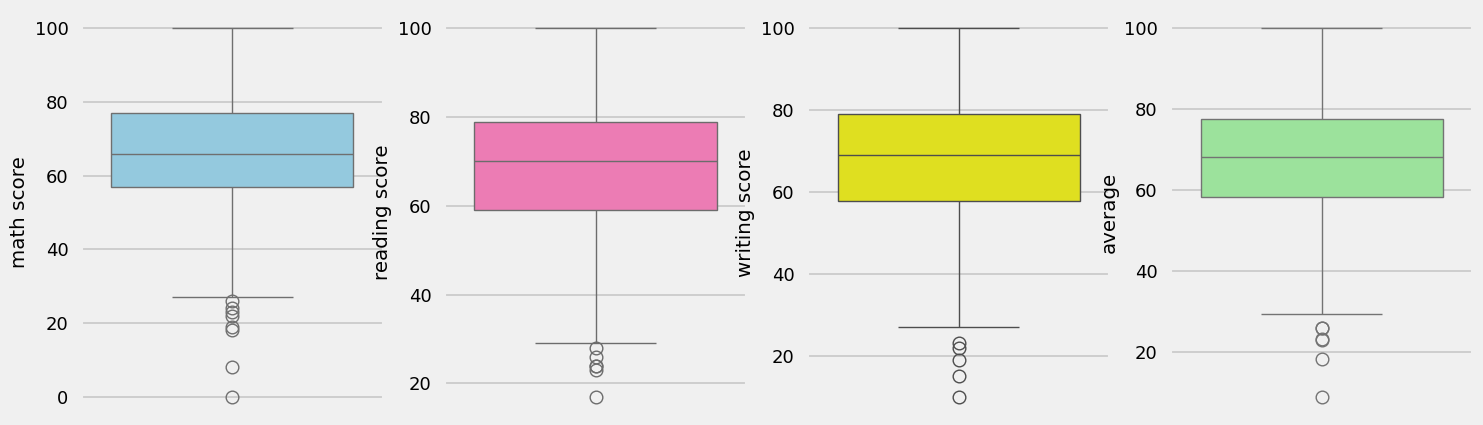

In [39]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'], color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'], color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing score'], color='yellow')
plt.subplot(144)
sns.boxplot(df['average'], color='lightgreen')

#### 4.4.7 Multivariate Analysis Using Pairplot

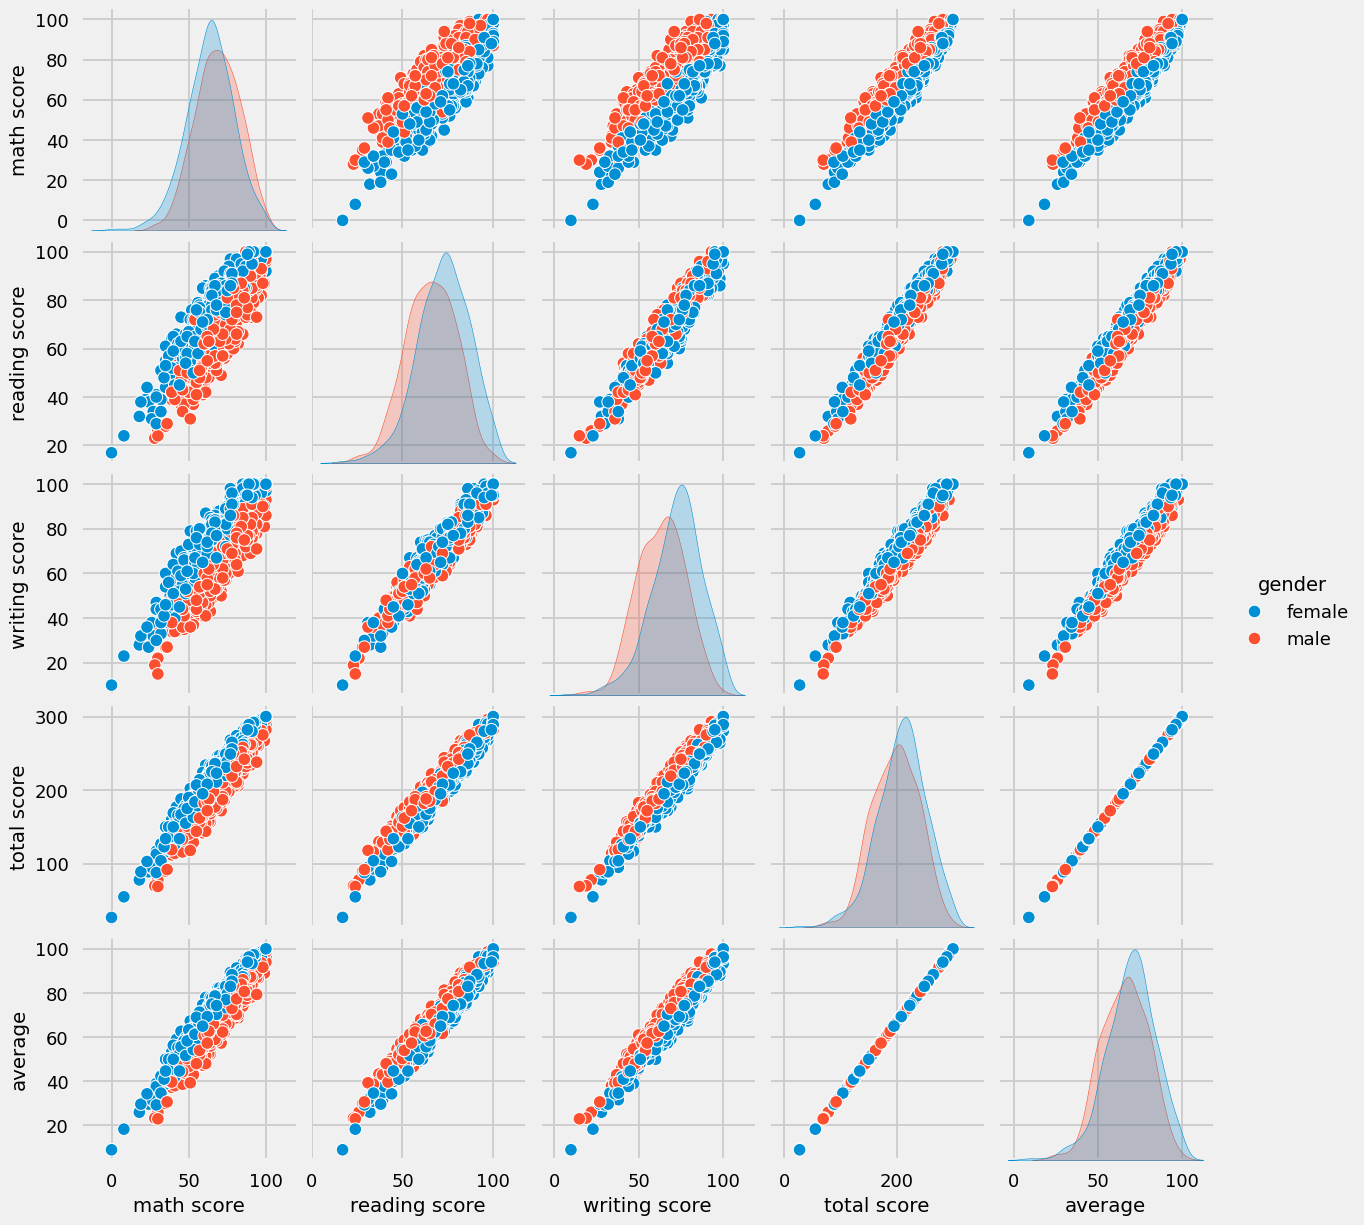

In [40]:
sns.pairplot(df,hue = 'gender')
plt.show()

Insights
* From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
* Student's Performance is related with lunch, race, parental level education
* Females lead in pass percentage and also are top-scorers
* Student's Performance is not much related with test preparation course
* Finishing preparation course is benefitial.